In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [5]:
# Load Vectorized Features

# train data
X_train = joblib.load("X_train.pkl")
X_train = X_train.toarray()

y_train = joblib.load("y_train.pkl")

# test data
X_test = joblib.load("X_test.pkl")
X_test = X_test.toarray()

y_test = joblib.load("y_test.pkl")

Spam ratio train    : 0.24863512283894448
Not spam ratio train: 0.7513648771610555
Spam ratio test     : 0.24818181818181817
Not spam ratio test : 0.7518181818181818


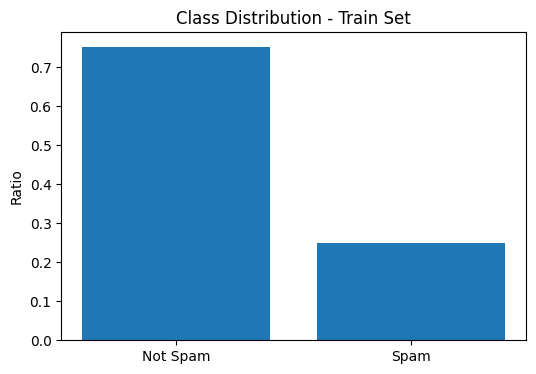

In [7]:
# Đặc điểm dataset
print("Spam ratio train    :", np.mean(y_train))
print("Not spam ratio train:", 1 - np.mean(y_train))

print("Spam ratio test     :", np.mean(y_test))
print("Not spam ratio test :", 1 - np.mean(y_test))

# trực quan
plt.figure(figsize=(6,4))

plt.bar(
    ["Not Spam", "Spam"],
    [
        1 - np.mean(y_train),
        np.mean(y_train)
    ]
)

plt.title("Class Distribution - Train Set")

plt.ylabel("Ratio")

plt.show()

Class Distribution Analysis

Tập dữ liệu có khoảng 24.86% email Spam và 75.14% email Not Spam.
Điều này cho thấy dữ liệu bị mất cân bằng ở mức vừa phải.

Do lớp Not Spam chiếm đa số, một mô hình đơn giản dự đoán tất cả email là Not Spam
đã có thể đạt Accuracy khoảng 75%.

Vì vậy Accuracy không phải chỉ số đáng tin cậy để đánh giá hiệu quả phát hiện Spam.
Cần xem thêm Precision, Recall và F1-score.

In [8]:
# Custom linear regression

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=750):
        self.lr = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape #Lấy kích thước
        # Khởi tạo trọng số
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            y_pred = self.predict(X)

            error = y_pred - y

            dw = (2 / n_samples) * np.dot(X.T, error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            loss = np.mean(error ** 2)
            self.loss_history.append(loss) #lưu để vẽ biểu đồ

            if epoch % 50 == 0:
                print(
                    f"Epoch {epoch:4d} | MSE = {loss:.6f}"
                )

    def predict(self, X):
        return (np.dot(X, self.weights) + self.bias) #CT Linear Regression
    
    # 1. Thêm predict_class()
    def predict_class(self, X, threshold=0.5):
        y_pred = self.predict(X)
        return (y_pred >= threshold).astype(int)

    

In [11]:
# Evaluation Metrics

# regression metric
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)



# 2. Thêm classificatipn metric
def classification_metrics(y_true, y_pred_class):

    accuracy = np.mean(y_pred_class == y_true)

    tp = np.sum((y_pred_class == 1) & (y_true == 1))
    tn = np.sum((y_pred_class == 0) & (y_true == 0))
    fp = np.sum((y_pred_class == 1) & (y_true == 0))
    fn = np.sum((y_pred_class == 0) & (y_true == 1))

    precision = tp / (tp + fp + 1e-8)

    recall = tp / (tp + fn + 1e-8)

    f1 = (
        2 * precision * recall
        / (precision + recall + 1e-8)
    )

    return accuracy, precision, recall, f1

In [10]:
# Train Model

model = LinearRegression(learning_rate=0.01,epochs=1000)

print("Training...")

model.fit(X_train, y_train)

Training...
Epoch    0 | MSE = 0.248635
Epoch   50 | MSE = 0.193023
Epoch  100 | MSE = 0.183925
Epoch  150 | MSE = 0.180789
Epoch  200 | MSE = 0.178448
Epoch  250 | MSE = 0.176243
Epoch  300 | MSE = 0.174091
Epoch  350 | MSE = 0.171980
Epoch  400 | MSE = 0.169907
Epoch  450 | MSE = 0.167871
Epoch  500 | MSE = 0.165873
Epoch  550 | MSE = 0.163910
Epoch  600 | MSE = 0.161983
Epoch  650 | MSE = 0.160091
Epoch  700 | MSE = 0.158232
Epoch  750 | MSE = 0.156407
Epoch  800 | MSE = 0.154614
Epoch  850 | MSE = 0.152853
Epoch  900 | MSE = 0.151124
Epoch  950 | MSE = 0.149425


In [12]:
# Prediction: Dùng trọng số đã học để dự đoán dữ liệu mới
# Regression output
y_pred = model.predict(X_test)

# Threshold 0.5
y_pred_class = (y_pred >= 0.5).astype(int)

In [13]:
# Regression Evaluation

print("MSE :", mse(y_test, y_pred))
print("RMSE:", rmse(y_test, y_pred))
print("MAE :", mae(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))

MSE : 0.1473123958936112
RMSE: 0.3838129699392807
MAE : 0.32893810311578725
R2  : 0.21049205154218398


In [14]:
# Classification Evaluation
accuracy, precision, recall, f1 = (
    classification_metrics(
        y_test,
        y_pred_class
    )
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Confusion Matrix
tp = np.sum((y_pred_class == 1) & (y_test == 1))
tn = np.sum((y_pred_class == 0) & (y_test == 0))
fp = np.sum((y_pred_class == 1) & (y_test == 0))
fn = np.sum((y_pred_class == 0) & (y_test == 1))

cm = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)
print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.7518181818181818
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Confusion Matrix:
          Pred 0  Pred 1
Actual 0     827       0
Actual 1     273       0


Phân tích:
    Accuracy khoảng 75%
    Precision = 0 => Không có email nào được dự đoán là Spam.
        Nguyên nhân: 
            TP = 0; FP = 0

    Recall = 0 => Model bỏ sót 100% email Spam.

    F1 Score = 0 => Khả năng phân loại lớp Spam gần như thất bại hoàn toàn.

Phân tích Confusion Matrix:
    Actual 0 → Pred 0: 
        827 email Not Spam được phân loại đúng.

    Actual 0 → Pred 1:
        0 email => ko có false alarm.

    Actual 1 → Pred 0:
        273 email Spam bị dự đoán thành Not Spam => vấn đề nghiêm trọng

    Actual 1 → Pred 1:
        0 email => Không phát hiện được spam nào.


Nhận xét:
    Accuracy đạt 75.18%, tuy nhiên kết quả này gây hiểu lầm.

    Tỷ lệ Not Spam trong tập test cũng xấp xỉ 75.18%.
    Điều này cho thấy mô hình đạt Accuracy cao chỉ nhờ dự đoán toàn bộ email là Not Spam.

    Confusion Matrix cho thấy:

    TP = 0
    FN = 273

    Mô hình không phát hiện được bất kỳ email Spam nào.

    Do đó Recall = 0 và F1-score = 0.

    Kết quả này chứng minh Linear Regression không phù hợp cho bài toán phân loại email Spam.

In [43]:
# Prediction Analysis

print("Min prediction:", y_pred.min())
print("Max prediction:", y_pred.max())
print("Mean prediction:", y_pred.mean())

print("\nFirst 20 regression outputs:")
print(y_pred[:20])

print("\nFirst 20 predicted classes:")
print(y_pred_class[:20])

# Unique prediction class
print(np.unique(y_pred_class))

Min prediction: 0.09147360417741512
Max prediction: 0.39701561638861355
Mean prediction: 0.24542149019854761

First 20 regression outputs:
[0.15331827 0.18938303 0.20167321 0.3341686  0.16112793 0.22081049
 0.23243937 0.21836338 0.23848465 0.23092581 0.14920245 0.1836027
 0.2005514  0.19186047 0.17590832 0.36337035 0.16835707 0.23980754
 0.24912015 0.31192856]

First 20 predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0]


Min prediction = 0.091
Max prediction = 0.397
    => Toàn bộ output < 0.5
    Nên y_pred_class = (y_pred >= 0.5) luôn cho 0.

Linear Regression đang học: 
    Spam rate ≈ 25% và dự đoán các gia trị như 
        0.15
        0.20
        0.25
        0.30
        gần giá trị trung bình.
    => Nó ko học được ranh giới phân loại Spam vs Not Spam


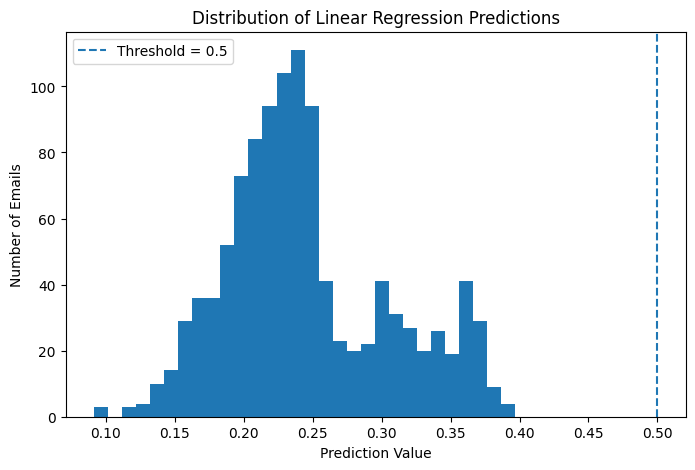

In [46]:
# Prediction Distribution (Histogram) => cho biết Prediction phân bố ở đâu
plt.figure(figsize=(8, 5))

plt.hist(
    y_pred,
    bins=30
)

plt.axvline(
    x=0.5,
    linestyle="--",
    label="Threshold = 0.5"
)

plt.title(
    "Distribution of Linear Regression Predictions"
)

plt.xlabel("Prediction Value")
plt.ylabel("Number of Emails")

plt.legend()

plt.show()

Nhận xét:
    Trong thí nghiệm, giá trị dự đoán nhỏ nhất là 0.091 và lớn nhất là 0.397. Do toàn bộ dự đoán đều < ngưỡng 0.5 nên mô hình không dự đoán bất kỳ email nào thuộc lớp Spam.

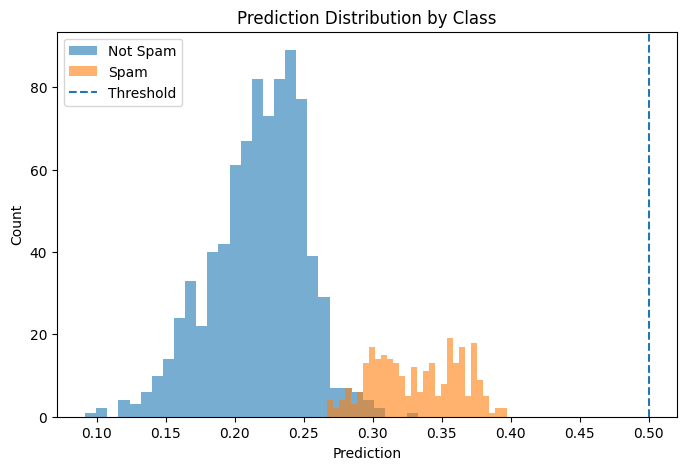

In [47]:
# Prediction Distribution by Class (Histogram theo Spam/Not Spam) => cho biết Prediction của Spam khác Prediction của Not Spam không?
plt.figure(figsize=(8,5))

plt.hist(
    y_pred[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Not Spam"
)

plt.hist(
    y_pred[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Spam"
)

plt.axvline(
    x=0.5,
    linestyle="--",
    label="Threshold"
)

plt.title(
    "Prediction Distribution by Class"
)

plt.xlabel("Prediction")
plt.ylabel("Count")

plt.legend()

plt.show()

    Biểu đồ trên cho thấy 2 histogram nằm chồng lên nhau => Linear Regression không tách được hai lớp

Nhận xét:
    Biểu đồ phân phối dự đoán theo từng lớp cho thấy các email Spam và Not Spam nhận được các giá trị dự đoán rất tương đồng. Hai phân phối chồng lấn đáng kể và đều tập trung trong vùng nhỏ hơn 0.5. Điều này chứng tỏ Linear Regression không học được ranh giới phân loại hiệu quả giữa hai lớp. Mô hình không thể tách biệt email Spam khỏi email Not Spam, dẫn đến Recall bằng 0 và không phát hiện được bất kỳ email Spam nào trong tập kiểm tra.

Kết luận: 
    Mặc dù Linear Regression hội tụ thành công và đạt Accuracy khoảng 75%, kết quả này chủ yếu đến từ việc dự đoán toàn bộ email là Not Spam. Confusion Matrix cho thấy TP = 0, FN = 273, Recall = 0 và F1-score = 0. Các biểu đồ phân phối dự đoán cũng cho thấy mô hình không tạo được sự khác biệt rõ ràng giữa hai lớp Spam và Not Spam. Do đó, Linear Regression không phù hợp cho bài toán phân loại email spam. Các mô hình phân loại như Logistic Regression phù hợp hơn vì được thiết kế để học ranh giới phân loại và tối ưu các hàm mất mát dành riêng cho classification.